In [65]:
import warnings
from sklearn import metrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rc('font', size=14)
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn import metrics
import statsmodels.stats.api as sms
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, classification_report
from sklearn.naive_bayes import GaussianNB

In [3]:
data = pd.read_csv('Salary.csv')

In [4]:
data.head()

,Age,Workclass,Fnlwgt,Education,Educational-num,Marital-status,Occupation,Relationship,Race,Gender,Capital-gain,Capital-loss,Hours-per-week,Native-country,Income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Age              45222 non-null  int64 
 1   Workclass        45222 non-null  object
 2   Fnlwgt           45222 non-null  int64 
 3   Education        45222 non-null  object
 4   Educational-num  45222 non-null  int64 
 5   Marital-status   45222 non-null  object
 6   Occupation       45222 non-null  object
 7   Relationship     45222 non-null  object
 8   Race             45222 non-null  object
 9   Gender           45222 non-null  object
 10  Capital-gain     45222 non-null  int64 
 11  Capital-loss     45222 non-null  int64 
 12  Hours-per-week   45222 non-null  int64 
 13  Native-country   45222 non-null  object
 14  Income           45222 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.2+ MB


In [6]:
data.shape

(45222, 15)

In [7]:
round(data.describe().T,2)

,count,mean,std,min,25%,50%,75%,max
Age,45222.0,38.55,13.22,17.0,28.00,37.0,47.0,90.0
Fnlwgt,45222.0,189734.73,105639.20,13492.0,117388.25,178316.0,237926.0,1490400.0
Educational-num,45222.0,10.12,2.55,1.0,9.00,10.0,13.0,16.0
Capital-gain,45222.0,1101.43,7506.43,0.0,0.00,0.0,0.0,99999.0
Capital-loss,45222.0,88.60,404.96,0.0,0.00,0.0,0.0,4356.0
Hours-per-week,45222.0,40.94,12.01,1.0,40.00,40.0,45.0,99.0


In [8]:
data.isnull().sum()

Age                0
Workclass          0
Fnlwgt             0
Education          0
Educational-num    0
Marital-status     0
Occupation         0
Relationship       0
Race               0
Gender             0
Capital-gain       0
Capital-loss       0
Hours-per-week     0
Native-country     0
Income             0
dtype: int64

In [9]:
data.isna().sum()

Age                0
Workclass          0
Fnlwgt             0
Education          0
Educational-num    0
Marital-status     0
Occupation         0
Relationship       0
Race               0
Gender             0
Capital-gain       0
Capital-loss       0
Hours-per-week     0
Native-country     0
Income             0
dtype: int64

In [10]:
data.isin([0]).sum()

Age                    0
Workclass              0
Fnlwgt                 0
Education              0
Educational-num        0
Marital-status         0
Occupation             0
Relationship           0
Race                   0
Gender                 0
Capital-gain       41432
Capital-loss       43082
Hours-per-week         0
Native-country         0
Income                 0
dtype: int64

In [11]:
df = data.copy()

In [12]:
for col in data.columns:
    if data[col].dtype == 'object':
        print(f"Column: {col}")
        print(f"Unique values: {data[col].unique()}")
        print('-'*60)

Column: Workclass
Unique values: ['Private' 'Local-gov' 'Self-emp-not-inc' 'Federal-gov' 'State-gov'
 'Self-emp-inc' 'Without-pay']
------------------------------------------------------------
Column: Education
Unique values: ['11th' 'HS-grad' 'Assoc-acdm' 'Some-college' '10th' 'Prof-school'
 '7th-8th' 'Bachelors' 'Masters' '5th-6th' 'Assoc-voc' '9th' 'Doctorate'
 '12th' '1st-4th' 'Preschool']
------------------------------------------------------------
Column: Marital-status
Unique values: ['Never-married' 'Married-civ-spouse' 'Widowed' 'Separated' 'Divorced'
 'Married-spouse-absent' 'Married-AF-spouse']
------------------------------------------------------------
Column: Occupation
Unique values: ['Machine-op-inspct' 'Farming-fishing' 'Protective-serv' 'Other-service'
 'Prof-specialty' 'Craft-repair' 'Adm-clerical' 'Exec-managerial'
 'Tech-support' 'Sales' 'Priv-house-serv' 'Transport-moving'
 'Handlers-cleaners' 'Armed-Forces']
-------------------------------------------------------

In [13]:
duplicates = data[data.duplicated()]
print(duplicates)

       Age         Workclass  Fnlwgt     Education  Educational-num  \
799     24           Private  194630     Bachelors               13   
10355   37           Private   52870     Bachelors               13   
10377   29           Private   36440     Bachelors               13   
12824   30           Private  180317     Assoc-voc               11   
14756   18      Self-emp-inc  378036          12th                8   
17078   39           Private  184659       HS-grad                9   
17924   19           Private  130431       5th-6th                3   
18225   41           Private  116391     Bachelors               13   
19024   25           Private  308144     Bachelors               13   
19528   25           Private  308144     Bachelors               13   
19741   90           Private   52386  Some-college               10   
22512   21           Private  243368     Preschool                1   
23530   21           Private  250051  Some-college               10   
23715 

In [14]:
round(data['Income'].value_counts(1)*100,2)

Income
<=50K    75.22
>50K     24.78
Name: proportion, dtype: float64

C:\Users\Hrishikesh\AppData\Local\Temp\ipykernel_19360\2317092479.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Age'])
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Age', ylabel='Density'>

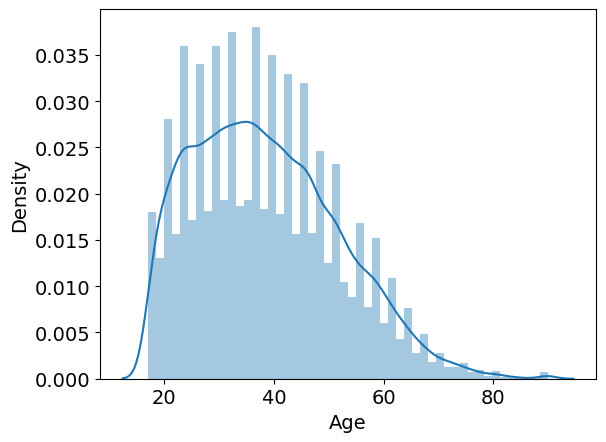

In [15]:
sns.distplot(data['Age'])

### Bivariate analysis

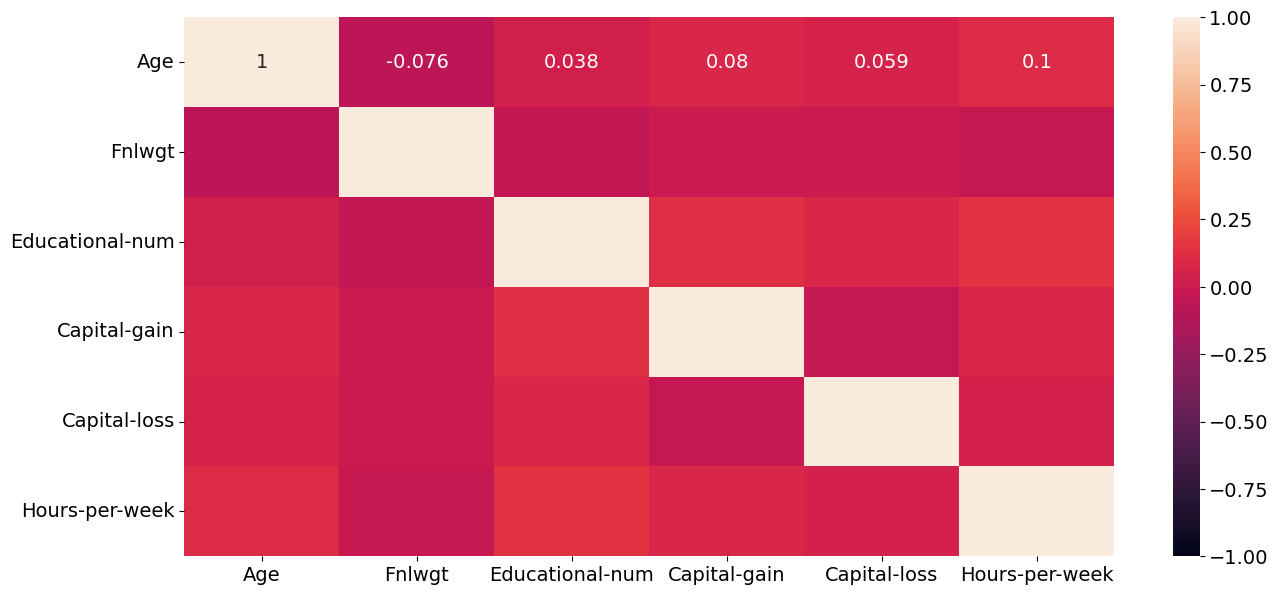

In [16]:
plt.figure(figsize=(15,7))
num_col = data.select_dtypes(include='number')
sns.heatmap(num_col.corr(),vmin=-1, vmax=1, annot=True)
plt.show();

C:\Users\Hrishikesh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to 

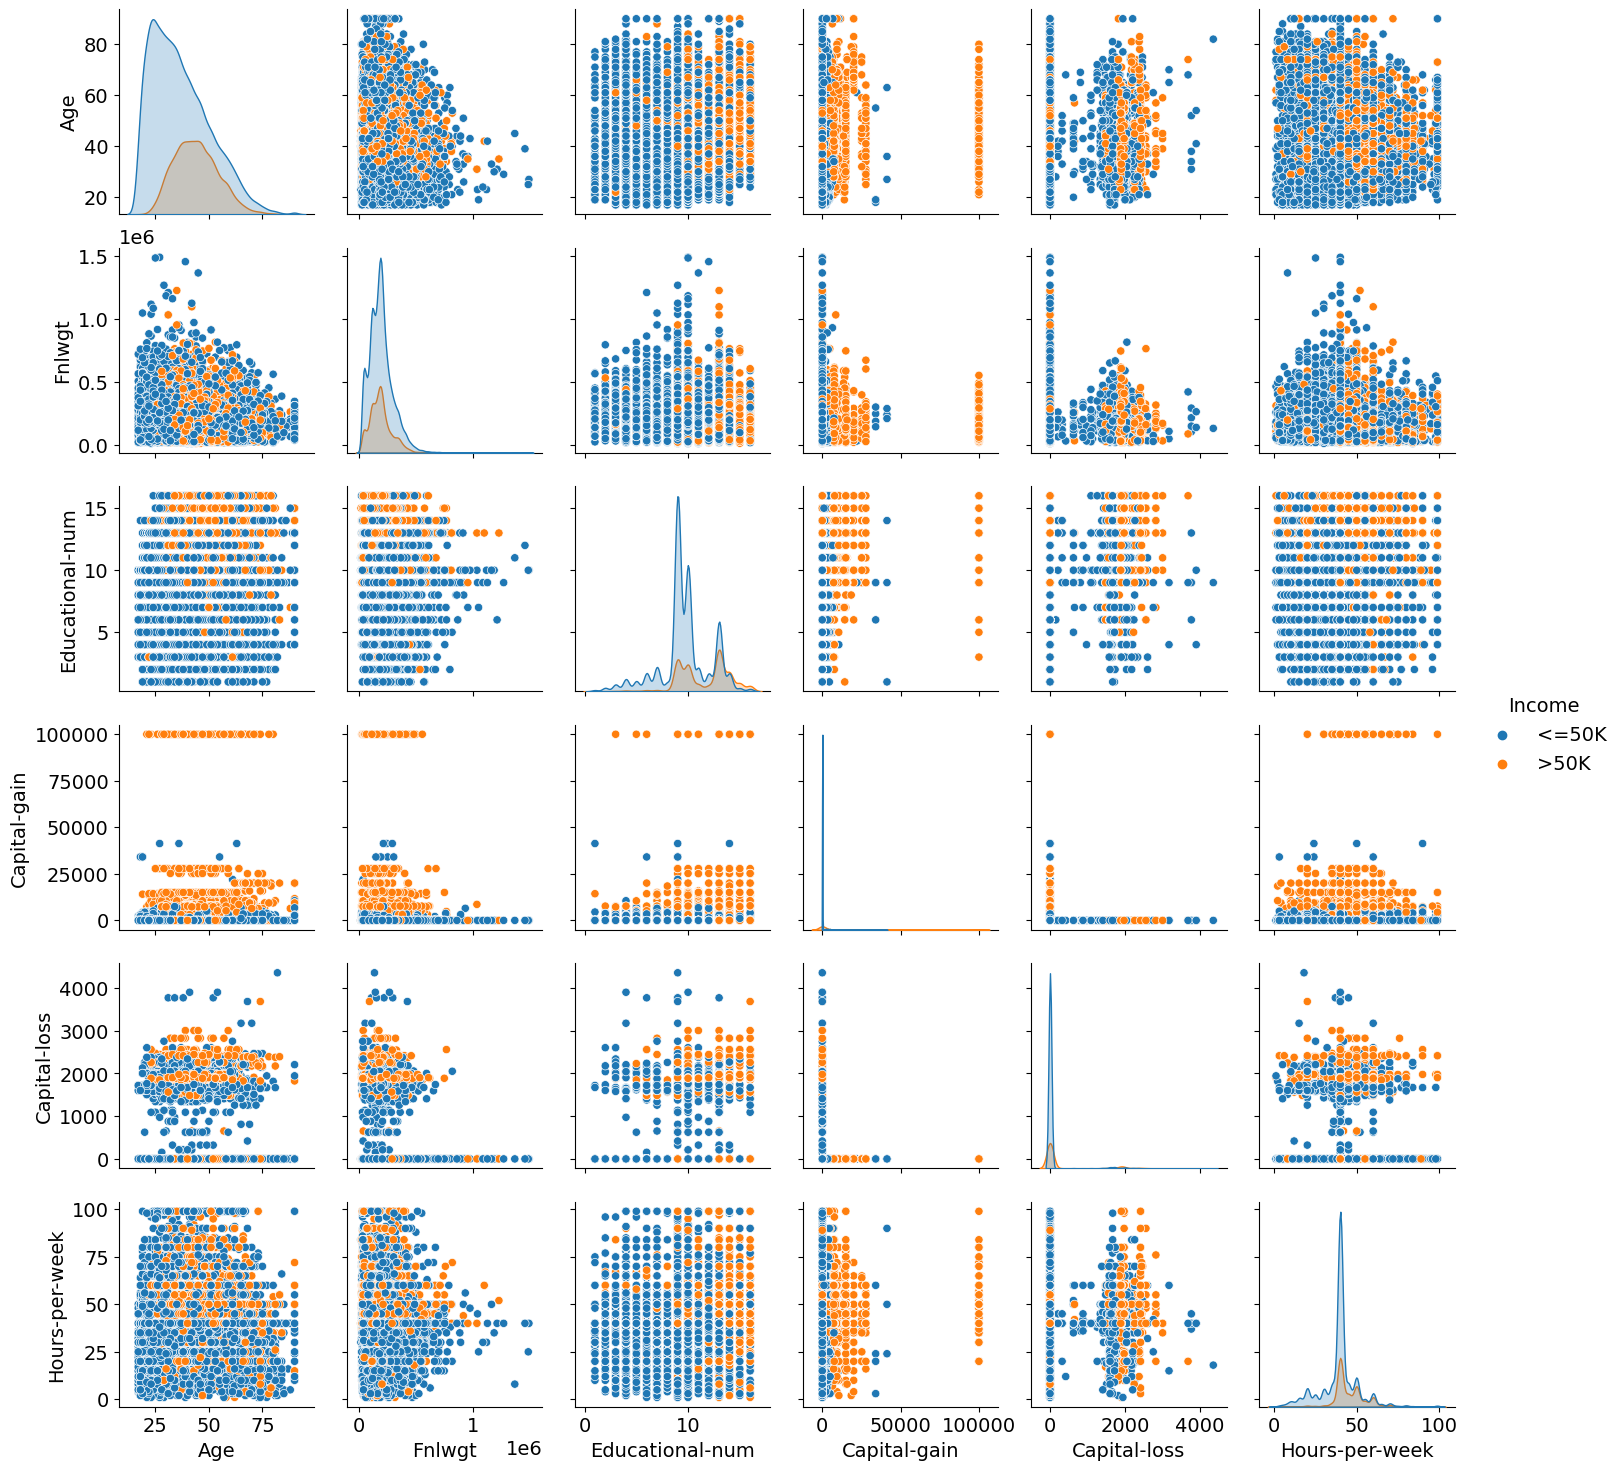

In [17]:
sns.pairplot(data, hue='Income')
plt.show();

In [18]:
workclass_dummies = pd.get_dummies(data['Workclass'],drop_first=True).astype(int)
data = pd.concat([data.drop('Workclass', axis=1), workclass_dummies], axis=1)

In [19]:
education_dummies = pd.get_dummies(data['Education'],drop_first=True).astype(int)
data = pd.concat([data.drop('Education',axis=1), education_dummies], axis=1)

In [20]:
marital_dummies = pd.get_dummies(data['Marital-status'],drop_first=True).astype(int)
data = pd.concat([data.drop('Marital-status', axis=1), marital_dummies], axis=1)

In [21]:
occupation_dummies= pd.get_dummies(data['Occupation'], drop_first=True).astype(int)
data = pd.concat([data.drop('Occupation', axis=1), occupation_dummies], axis=1)

In [22]:
relationship_dummies = pd.get_dummies(data['Relationship'], drop_first=True).astype(int)
data = pd.concat([data.drop('Relationship', axis=1), relationship_dummies], axis=1)

In [23]:
race_dummies = pd.get_dummies(data['Race'], drop_first=True).astype(int)
data = pd.concat([data.drop('Race', axis=1), race_dummies], axis=1)

In [24]:
gender_dummies = pd.get_dummies(data['Gender'], drop_first=True).astype(int)
data = pd.concat([data.drop('Gender', axis=1), gender_dummies], axis=1)

In [25]:
native_dummies = pd.get_dummies(data['Native-country'], drop_first=True).astype(int)
data = pd.concat([data.drop('Native-country', axis=1), native_dummies], axis=1)

In [26]:
data['Income'] = data['Income'].map({'<=50K' : 0, '>50K': 1})

In [27]:
data.head()

,Age,Fnlwgt,Educational-num,Capital-gain,Capital-loss,Hours-per-week,Income,Local-gov,Private,Self-emp-inc,...,Portugal,Puerto-Rico,Scotland,South,Taiwan,Thailand,Trinadad&Tobago,United-States,Vietnam,Yugoslavia
0,25,226802,7,0,0,40,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
1,38,89814,9,0,0,50,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
2,28,336951,12,0,0,40,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3,44,160323,10,7688,0,40,1,0,1,0,...,0,0,0,0,0,0,0,1,0,0
4,34,198693,6,0,0,30,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


In [28]:
columns = data.columns

In [29]:
vif_series = pd.Series([variance_inflation_factor(data.values, i) for i in range(data.shape[1])],
                       index=columns,
                       dtype=float)
print(vif_series)

Age                   1.706119
Fnlwgt                1.061264
Educational-num    6742.143053
Capital-gain          1.093186
Capital-loss          1.034778
                      ...     
Thailand              2.118694
Trinadad&Tobago       2.034385
United-States       144.018665
Vietnam               4.194157
Yugoslavia            1.923658
Length: 97, dtype: float64


In [30]:
high_vif_cols = vif_series[vif_series > 10].index.tolist()
print("Highly collinear columns:", high_vif_cols)

Highly collinear columns: ['Educational-num', 'Assoc-acdm', 'Assoc-voc', 'Bachelors', 'Doctorate', 'HS-grad', 'Masters', 'Prof-school', 'Some-college', 'Married-civ-spouse', 'Not-in-family', 'Own-child', 'Unmarried', 'White', 'Mexico', 'Philippines', 'United-States']


In [31]:
data.drop(columns=['Educational-num',
                   'Assoc-acdm',
                   'Assoc-voc',
                   'Bachelors',
                   'Doctorate',
                   'HS-grad',
                   'Masters',
                   'Prof-school',
                   'Some-college',
                   'Married-civ-spouse',
                   'Not-in-family',
                   'Own-child',
                   'Unmarried',
                   'White',
                   'Mexico',
                   'Philippines',
                   'United-States'], axis=1)

,Age,Fnlwgt,Capital-gain,Capital-loss,Hours-per-week,Income,Local-gov,Private,Self-emp-inc,Self-emp-not-inc,...,Poland,Portugal,Puerto-Rico,Scotland,South,Taiwan,Thailand,Trinadad&Tobago,Vietnam,Yugoslavia
0,25,226802,0,0,40,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,38,89814,0,0,50,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,28,336951,0,0,40,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,44,160323,7688,0,40,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,34,198693,0,0,30,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45217,27,257302,0,0,38,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
45218,40,154374,0,0,40,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
45219,58,151910,0,0,40,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
45220,22,201490,0,0,20,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [32]:
scaler = StandardScaler()
x = scaler.fit_transform(data.drop(['Income'], axis=1))
y = data['Income']

In [33]:
y.value_counts(1)*100

Income
0    75.215603
1    24.784397
Name: proportion, dtype: float64

In [34]:
clf = LinearDiscriminantAnalysis()
model = clf.fit(x,y)
model

LinearDiscriminantAnalysis()

In [35]:
pred_class = model.predict(x)
data['Prediction'] = pred_class

In [36]:
cm = confusion_matrix(y, pred_class)
custom_cm = pd.DataFrame([[cm[1,1],cm[1,0]],
                          [cm[0,1],cm[0,0]]],
                         columns=['Predicted Positive','Predicted Negative'],
                         index=['Actual Positive','Actual Negative'])
custom_cm

,Predicted Positive,Predicted Negative
Actual Positive,6414,4794
Actual Negative,2470,31544


In [37]:
print(classification_report(y, pred_class))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90     34014
           1       0.72      0.57      0.64     11208

    accuracy                           0.84     45222
   macro avg       0.80      0.75      0.77     45222
weighted avg       0.83      0.84      0.83     45222



In [39]:
DS = x @ coef.T - 1.89800

NameError: name 'coef' is not defined

In [40]:
s1, s2 = 0, 0  # Counters for class 1 and class 0

for i, score in enumerate(DS):
    print(f"FOR Row: {i}  {x[i]}")
    
    if score >= 0:
        print(f"--> DS: {score:.4f} >= 0 → Classify as 1")
        s1 += 1
    else:
        print(f"--> DS: {score:.4f} < 0 → Classify as 0")
        s2 += 1
    
    print("-" * 80)

NameError: name 'DS' is not defined

### Logistic regression

In [41]:
df = pd.read_csv('Salary.csv')

In [42]:
df.head()

,Age,Workclass,Fnlwgt,Education,Educational-num,Marital-status,Occupation,Relationship,Race,Gender,Capital-gain,Capital-loss,Hours-per-week,Native-country,Income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K


In [43]:
x = df.drop(['Income'],axis=1)
y = df['Income']
y = y.map({'<=50K':0,'>50K':1})
x = add_constant(x)
x = pd.get_dummies(x, drop_first=True)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, stratify = y, random_state = 1)

In [44]:
lg = LogisticRegression()
lg.fit(x_train,y_train)

LogisticRegression()

In [45]:
pred_train = lg.predict(x_train)

In [46]:
print(classification_report(y_train, pred_train))

              precision    recall  f1-score   support

           0       0.80      0.97      0.87     23809
           1       0.71      0.26      0.38      7846

    accuracy                           0.79     31655
   macro avg       0.75      0.61      0.63     31655
weighted avg       0.78      0.79      0.75     31655



In [47]:
cm = confusion_matrix(y_train, pred_train)
custom_cm = pd.DataFrame([[cm[1,1],cm[1,0]],
                          [cm[0,1],cm[0,0]]],
                         columns=['Predicted Positive','Predicted Negative'],
                         index=['Actual Positive','Actual Negative'])
custom_cm

,Predicted Positive,Predicted Negative
Actual Positive,2031,5815
Actual Negative,829,22980


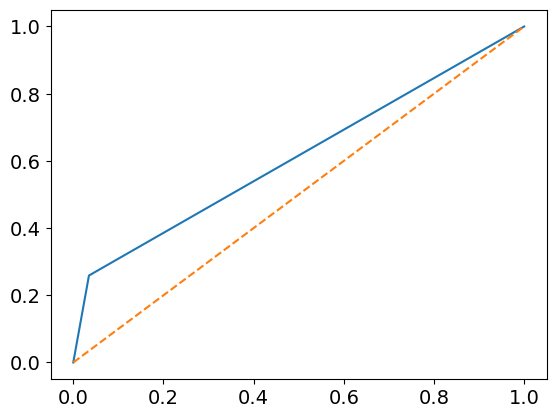

In [48]:
fpr,tpr,_ = roc_curve(y_train, lg.predict(x_train))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],linestyle='--')
plt.show();

### Naive Bayes Model

In [50]:
df.shape

(45222, 15)

In [54]:
df['Income'].value_counts(1)

Income
<=50K    0.752156
>50K     0.247844
Name: proportion, dtype: float64

In [55]:
df_nb = df.copy()

In [61]:
df_nb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Age              45222 non-null  int64 
 1   Workclass        45222 non-null  object
 2   Fnlwgt           45222 non-null  int64 
 3   Education        45222 non-null  object
 4   Educational-num  45222 non-null  int64 
 5   Marital-status   45222 non-null  object
 6   Occupation       45222 non-null  object
 7   Relationship     45222 non-null  object
 8   Race             45222 non-null  object
 9   Gender           45222 non-null  object
 10  Capital-gain     45222 non-null  int64 
 11  Capital-loss     45222 non-null  int64 
 12  Hours-per-week   45222 non-null  int64 
 13  Native-country   45222 non-null  object
 14  Income           45222 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.2+ MB


In [63]:
x_nb = df_nb.drop(['Income'], axis=1)
y_nb = df_nb['Income']
x_nb = pd.get_dummies(x_nb, drop_first=True).astype(int)
x_train, x_test, y_train, y_test = train_test_split(x_nb, y_nb, test_size = 0.25, stratify = y, random_state =1)
x_train.head()

,Age,Fnlwgt,Educational-num,Capital-gain,Capital-loss,Hours-per-week,Workclass_Local-gov,Workclass_Private,Workclass_Self-emp-inc,Workclass_Self-emp-not-inc,...,Native-country_Portugal,Native-country_Puerto-Rico,Native-country_Scotland,Native-country_South,Native-country_Taiwan,Native-country_Thailand,Native-country_Trinadad&Tobago,Native-country_United-States,Native-country_Vietnam,Native-country_Yugoslavia
38068,44,56651,13,0,0,52,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
26433,28,66473,9,0,0,40,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
29733,27,205440,6,0,0,40,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
37274,29,210959,12,0,0,40,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
26992,26,136951,9,0,0,40,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0


In [64]:
salary_model = GaussianNB()
salary_model.fit(x_train, y_train.ravel())

GaussianNB()

In [66]:
salary_train_predict = salary_model.predict(x_train)
accuracy_score(y_train, salary_train_predict)

0.7870326689468098

In [68]:
salary_test_predict = salary_model.predict(x_test)
accuracy_score(y_test, salary_test_predict)

0.7940916327613656

In [69]:
cm = confusion_matrix(y_test, salary_test_predict)
custom_cm = pd.DataFrame([[cm[1,1],cm[1,0]],
                          [cm[0,1],cm[0,0]]],
                         columns=['Predicted Positive','Predicted Negative'],
                         index=['Actual Positive','Actual Negative'])
custom_cm

,Predicted Positive,Predicted Negative
Actual Positive,895,1907
Actual Negative,421,8083


In [70]:
print(classification_report(y_test, salary_test_predict))

              precision    recall  f1-score   support

       <=50K       0.81      0.95      0.87      8504
        >50K       0.68      0.32      0.43      2802

    accuracy                           0.79     11306
   macro avg       0.74      0.63      0.65     11306
weighted avg       0.78      0.79      0.77     11306

